# Stockholm Statistikområden (RegSO) - Analys & Visualisering

Data från SCB med matplotlib-grafer och DuckDB SQL-analyser

**OBS:** RegSO (Regionala statistikområden) är SCB:s geografiska indelning för statistik.  
Detta är INTE samma som Stockholms stads administrativa stadsdelsnämnder.

- **127 RegSO-områden** i Stockholms kommun
- **14 stadsdelsnämnder** (administrativa enheter)
- RegSO är finare uppdelning och liknar "stadsdelar i folkmun"

## Datakällor

- **Folkmängd (TAB6574):** Befolkning per åldersgrupp och område
- **Hushåll (TAB6568):** Hushållstyper per område
- **Boende (TAB6638):** Upplåtelseformer per område

## Workflow

1. **Hämta RAW data** - All detalj (17 åldersgrupper, alla hushållstyper, etc.)
2. **Exportera RAW** - Spara detaljerad data till CSV
3. **Aggregera** - Kombinera och beräkna nyckeltal
4. **Analysera** - SQL-queries och visualiseringar
5. **Exportera aggregerad** - Färdig data för dashboard

---
## Setup & Konfiguration

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS & KONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

import requests      # För HTTP-anrop till SCB API
import pandas as pd  # För dataanalys och manipulation
import itertools     # För att skapa kartesiska produkter (kombinationer)
import matplotlib.pyplot as plt  # För visualiseringar
import matplotlib as mpl
import duckdb        # För SQL-analyser på DataFrames
import numpy as np
from pathlib import Path  # För plattformsoberoende filsökvägar

# ───────────────────────────────────────────────────────────────────────────
# Matplotlib styling
# ───────────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')  # Professionell stil med rutnät
mpl.rcParams['figure.figsize'] = (12, 6)  # Standardstorlek för grafer
mpl.rcParams['font.size'] = 10            # Basstorlek för text

# ───────────────────────────────────────────────────────────────────────────
# Sökvägar
# ───────────────────────────────────────────────────────────────────────────
# Mappstruktur:
#   UrbanPulse/
#   ├── data_files/          # CSV-filer lagras här
#   └── EDA/
#       ├── outputs/         # Grafer och visualiseringar
#       └── notebook.ipynb   # Denna fil

BASE_DIR   = Path.cwd()                      # EDA/ (där denna notebook ligger)
DATA_DIR   = BASE_DIR.parent / "data_files"  # ../data_files/
OUTPUT_DIR = BASE_DIR / "outputs"            # EDA/outputs/

# Skapa mappar om de inte finns (parents=True skapar även föräldramappar)
DATA_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# ───────────────────────────────────────────────────────────────────────────
# SCB API-konfiguration
# ───────────────────────────────────────────────────────────────────────────
BASE_URL = "https://statistikdatabasen.scb.se/api/v2"  # SCB:s API v2
LANG     = "sv"  # Språk för labels och metadata

# Tabellnummer från SCB
TABLE_FOLKM_DESO = "TAB6574"  # Folkmängd efter region, ålder, kön
TABLE_HUSHALL    = "TAB6568"  # Hushållstyp efter region
TABLE_BOENDE     = "TAB6638"  # Upplåtelseform efter region

# API-optimering: Hämta max 10 områden per request för att undvika timeout
BATCH_SIZE = 10

print("✓ Bibliotek importerade")
print(f"  DATA_DIR   : {DATA_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")

✓ Bibliotek importerade
  DATA_DIR   : c:\Users\chris\Documents\github\UrbanPulse\data_files
  OUTPUT_DIR : c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs


---
## Hjälpfunktioner

Dessa funktioner hanterar kommunikation med SCB:s API och databearbetning.

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# HJÄLPFUNKTIONER FÖR SCB API
# ═══════════════════════════════════════════════════════════════════════════

def get_metadata(table_id):
    """Hämta metadata från SCB API för en tabell.
    
    Metadata innehåller information om:
    - Vilka dimensioner som finns (Region, Ålder, Kön, etc.)
    - Vilka värden varje dimension kan ha
    - Labels/namn för alla värden
    
    Args:
        table_id (str): SCB tabellnummer, ex. 'TAB6574'
        
    Returns:
        dict: JSON med tabellstruktur och alla möjliga värden
        
    Exempel:
        >>> meta = get_metadata('TAB6574')
        >>> meta['dimension']['Alder']['category']['label']
        {'0-4': '0-4 år', '5-9': '5-9 år', ...}
    """
    url = f"{BASE_URL}/tables/{table_id}/metadata?lang={LANG}"
    r = requests.get(url)
    r.raise_for_status()  # Kastar exception vid HTTP-fel
    return r.json()


def stockholm_regso_koder(meta):
    """Filtrera ut RegSO-koder för Stockholm från metadata.
    
    SCB:s tabeller innehåller data för hela Sverige. Denna funktion
    plockar ut bara de 127 RegSO-områdena i Stockholms kommun.
    
    RegSO-koder ser ut så här: '0180R001_RegSO2025'
    - '0180' = Stockholms kommun
    - 'R001' = Regionalt statistikområde nummer 1
    - '_RegSO2025' = Suffix som indikerar RegSO-indelning för 2025
    
    Args:
        meta (dict): Metadata från get_metadata()
        
    Returns:
        dict: {region_kod: områdesnamn} för alla 127 områden
              Ex: {'0180R001_RegSO2025': 'Stockholm (Abrahamsberg)'}
    """
    region_cats   = meta["dimension"]["Region"]["category"]["index"]
    region_labels = meta["dimension"]["Region"]["category"]["label"]
    
    # Filtrera: Börjar med 0180 (Stockholm) OCH slutar med _RegSO2025
    regso = {k: region_labels[k] for k in region_cats.keys()
             if k.startswith("0180") and k.endswith("_RegSO2025")}
    return regso


def jsonstat2_to_df(data, region_namn_map):
    """Konvertera JSON-stat2 format till pandas DataFrame.
    
    SCB returnerar data i JSON-stat2-format, vilket är optimerat för
    överföring men inte praktiskt för analys. Denna funktion omvandlar
    till en "long format" DataFrame där varje rad är en observation.
    
    Exempel på transformation:
    JSON-stat2:
      dimensions: [Region, Alder]
      values: [100, 150, 200, 250]
    
    Blir DataFrame:
      Region          Alder     value
      0180R001_...    0-4 år    100
      0180R001_...    5-9 år    150
      0180R002_...    0-4 år    200
      0180R002_...    5-9 år    250
    
    Args:
        data (dict): JSON-stat2 response från SCB API
        region_namn_map (dict): Mapping från regionkod till namn
        
    Returns:
        DataFrame: Data med kolumner för varje dimension + 'value' + 'Statistikområde'
    """
    # Dimensioner i ordning (ex: ['Region', 'Alder', 'Kon', 'Tid'])
    dims = data["id"]
    
    # Värden i samma ordning som dimensionerna är organiserade
    values = data["value"]
    
    # Hämta alla möjliga värden för varje dimension
    dim_vals = []
    for d in dims:
        if d == "Region":
            # För Region behåller vi koderna (används för att matcha med region_namn_map)
            dim_vals.append(list(data["dimension"][d]["category"]["index"].keys()))
        else:
            # För andra dimensioner tar vi de läsbara labels
            dim_vals.append(list(data["dimension"][d]["category"]["label"].values()))
    
    # Skapa kartesisk produkt av alla dimensioner
    # Ex: [Region1, Region2] × [0-4 år, 5-9 år] = 4 kombinationer
    df = pd.DataFrame(list(itertools.product(*dim_vals)), columns=dims)
    df["value"] = values
    
    # ───────────────────────────────────────────────────────────────────────
    # Städa områdesnamn
    # ───────────────────────────────────────────────────────────────────────
    # SCB returnerar namn som "Stockholm (Abrahamsberg)"
    # Vi vill bara ha "Abrahamsberg"
    df["Statistikområde"] = df["Region"].map(
        lambda x: region_namn_map.get(x, x).replace("Stockholm (", "").replace(")", "")
    )
    
    # Flytta Statistikområde till andra positionen (efter Region)
    # Blir lättare att läsa: Region, Statistikområde, Alder, Kon, ...
    cols = df.columns.tolist()
    cols.insert(1, cols.pop(cols.index("Statistikområde")))
    return df[cols]


def fetch_batch(table_id, regso_map, extra_filters):
    """Hämta data från SCB API i batcher.
    
    SCB:s API har begränsningar på hur stora requests man kan göra.
    Denna funktion delar upp hämtningen i mindre batcher om 10 områden
    åt gången, vilket förhindrar timeouts och serverproblem.
    
    Varför batcher?
    - 127 områden × 17 åldersgrupper = 2159 datapunkter
    - För stora requests kan överbelasta servern
    - Batch-strategi: 10 områden åt gången = 13 requests totalt
    
    Args:
        table_id (str): SCB tabellnummer
        regso_map (dict): Dictionary med regionkoder från stockholm_regso_koder()
        extra_filters (dict): Filter för andra dimensioner
                             Ex: {'Alder': ['0-4 år', '5-9 år'], 
                                  'Tid': ['2024']}
    
    Returns:
        DataFrame eller None: Sammanslagna data från alla lyckade batcher.
                             Returnerar None om inga batcher lyckades.
    
    Exempel:
        >>> meta = get_metadata('TAB6574')
        >>> regso = stockholm_regso_koder(meta)
        >>> df = fetch_batch('TAB6574', regso, {
        ...     'Alder': ['0-4 år', '5-9 år'],
        ...     'Tid': ['2024']
        ... })
        Hämtar 127 områden i 13 batcher...
          ✓ 5/13 batcher klara
          ✓ 10/13 batcher klara
        ✅ Klart – 254 rader
    """
    # Dela upp regionkoder i batcher om 10
    koder = list(regso_map.keys())
    batches = [koder[i:i + BATCH_SIZE] for i in range(0, len(koder), BATCH_SIZE)]
    print(f"Hämtar {len(koder)} områden i {len(batches)} batcher...")
    
    dfs = []  # Lista för att samla DataFrames från varje batch
    
    for i, batch in enumerate(batches, 1):
        # ───────────────────────────────────────────────────────────────────
        # Bygg URL-parametrar
        # ───────────────────────────────────────────────────────────────────
        params = [
            f"lang={LANG}",
            "outputFormat=JSON-stat2",  # Välj JSON-stat2-format
            f"valueCodes[Region]={','.join(batch)}",  # Regions för denna batch
        ]
        
        # Lägg till övriga filter (Alder, Kon, Tid, etc.)
        for dim, vals in extra_filters.items():
            # Hantera specialtecken: + måste URL-encodas till %2B
            encoded_vals = [v.replace("+", "%2B") for v in vals]
            params.append(f"valueCodes[{dim}]={','.join(encoded_vals)}")
        
        url = f"{BASE_URL}/tables/{table_id}/data?" + "&".join(params)
        
        # ───────────────────────────────────────────────────────────────────
        # Försök hämta data
        # ───────────────────────────────────────────────────────────────────
        try:
            r = requests.get(url, timeout=15)  # 15 sekunders timeout
            if r.status_code == 200:
                df = jsonstat2_to_df(r.json(), regso_map)
                dfs.append(df)
            else:
                # Logga HTTP-fel men fortsätt med nästa batch
                print(f"  ⚠️  Batch {i}: HTTP {r.status_code}")
        except Exception as e:
            # Logga andra fel (timeout, nätverksproblem, etc.)
            print(f"  ⚠️  Batch {i}: {str(e)[:100]}")
        
        # Progressindikator var 5:e batch
        if i % 5 == 0:
            print(f"  ✓ {i}/{len(batches)} batcher klara")
    
    # ───────────────────────────────────────────────────────────────────────
    # Sammanfoga resultat
    # ───────────────────────────────────────────────────────────────────────
    if not dfs:
        # Alla batcher misslyckades
        return None
    
    # Slå ihop alla DataFrames till en
    result = pd.concat(dfs, ignore_index=True)
    print(f"✅ Klart – {len(result)} rader")
    return result

print("✓ Funktioner laddade")

✓ Funktioner laddade


---
## 1. FOLKMÄNGD MED ALLA ÅLDERSGRUPPER

**Viktigt:** Vi hämtar ALLA 17 åldersgrupper, inte bara totalsumman.

Detta ger oss:
- Detaljerad åldersstruktur per område
- Möjlighet att analysera barnfamiljer, unga vuxna, pensionärer
- Flexibilitet att skapa egna ålderskategorier

**Resultat:** 127 områden × 17 åldersgrupper = 2159 rader

In [35]:
print("\n" + "="*60)
print("FOLKMÄNGD MED ÅLDERSGRUPPER")
print("="*60)

# ───────────────────────────────────────────────────────────────────────────
# Hämta metadata för att se vilka åldersgrupper som finns
# ───────────────────────────────────────────────────────────────────────────
meta_folkm  = get_metadata(TABLE_FOLKM_DESO)
regso_folkm = stockholm_regso_koder(meta_folkm)
print(f"  {len(regso_folkm)} RegSO-områden hittade")

# ───────────────────────────────────────────────────────────────────────────
# Plocka ut alla åldersgrupper (utom 'totalt')
# ───────────────────────────────────────────────────────────────────────────
# Metadata innehåller kategorier som: 'totalt', '0-4', '5-9', '10-14', ...
# Vi vill ha de specifika åldersgrupperna, inte totalsumman
alder_cats = meta_folkm["dimension"]["Alder"]["category"]["index"]
aldersgrupper = [k for k in alder_cats.keys() if k != 'totalt']
print(f"  Hämtar {len(aldersgrupper)} åldersgrupper")

# ───────────────────────────────────────────────────────────────────────────
# Hämta data från API
# ───────────────────────────────────────────────────────────────────────────
df_folkm = fetch_batch(TABLE_FOLKM_DESO, regso_folkm, {
    "Alder":        aldersgrupper,  # ALLA 17 åldersgrupper (inte bara totalt)
    "Kon":          ["1+2"],        # Män + Kvinnor (totalt för båda könen)
    "ContentsCode": ["000007Y7"],   # Kod för "Folkmängd"
    "Tid":          ["2024"],       # År 2024
})

# ───────────────────────────────────────────────────────────────────────────
# Verifiera resultat
# ───────────────────────────────────────────────────────────────────────────
print(f"\n📊 Resultat:")
print(f"   {len(df_folkm)} rader (förväntat: {len(regso_folkm)} × {len(aldersgrupper)} = {len(regso_folkm) * len(aldersgrupper)})")
print(f"   {df_folkm['Statistikområde'].nunique()} områden")
print(f"   {df_folkm['Alder'].nunique()} åldersgrupper")


FOLKMÄNGD MED ÅLDERSGRUPPER
  127 RegSO-områden hittade
  Hämtar 17 åldersgrupper
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 2159 rader

📊 Resultat:
   2159 rader (förväntat: 127 × 17 = 2159)
   127 områden
   17 åldersgrupper


---
## 2. HUSHÅLL MED ALLA HUSHÅLLSTYPER

**Viktigt:** Vi hämtar ALLA hushållstyper, inte bara totalsumman.

Hushållstyper inkluderar:
- sammanboende med barn
- sammanboende utan barn
- ensamstående med barn
- ensamstående utan barn
- övriga hushåll
- **totalt antal hushåll** (summan av ovanstående)

**OBS:** När vi senare ska beräkna "totalt hushåll per område" använder vi BARA
raden "totalt antal hushåll", inte summan av alla rader (det skulle dubbelräkna).

**Resultat:** 127 områden × ~6 hushållstyper = ~762 rader

In [36]:
print("\n" + "="*60)
print("HUSHÅLL MED ALLA TYPER")
print("="*60)

meta_hushall  = get_metadata(TABLE_HUSHALL)
regso_hushall = stockholm_regso_koder(meta_hushall)
print(f"  {len(regso_hushall)} RegSO-områden hittade")

# ───────────────────────────────────────────────────────────────────────────
# Plocka ut alla hushållstyper
# ───────────────────────────────────────────────────────────────────────────
# Vi hämtar alla kategorier inklusive "totalt antal hushåll"
# Detta ger oss både detaljuppdelning OCH totalsumma
hushall_cats = meta_hushall["dimension"]["Hushallstyp"]["category"]["index"]
print(f"  Hämtar {len(hushall_cats)} hushållstyper")

df_hushall = fetch_batch(TABLE_HUSHALL, regso_hushall, {
    "Hushallstyp":  list(hushall_cats.keys()),  # ALLA typer inkl. totalt
    "ContentsCode": ["000007Y1"],               # Kod för "Antal hushåll"
    "Tid":          ["2024"],
})

print(f"\n📊 Resultat:")
print(f"   {len(df_hushall)} rader")
print(f"   Hushållstyper: {df_hushall['Hushallstyp'].unique()}")


HUSHÅLL MED ALLA TYPER
  127 RegSO-områden hittade
  Hämtar 6 hushållstyper
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 762 rader

📊 Resultat:
   762 rader
   Hushållstyper: ['sammanboende med barn' 'sammanboende utan barn' 'ensamstående med barn'
 'ensamstående utan barn' 'övriga hushåll' 'totalt antal hushåll']


---
## 3. BOENDE MED ALLA UPPLÅTELSEFORMER

Upplåtelseformer:
- **hyresrätt** - Hyr av fastighetsägare
- **bostadsrätt** - Medlem i bostadsrättsförening
- **äganderätt** - Äger fastigheten (villa/radhus)
- **uppgift saknas** - Okänd upplåtelseform

**Resultat:** 127 områden × 4 former = 508 rader

In [37]:
print("\n" + "="*60)
print("BOENDE MED ALLA UPPLÅTELSEFORMER")
print("="*60)

meta_boende  = get_metadata(TABLE_BOENDE)
regso_boende = stockholm_regso_koder(meta_boende)
print(f"  {len(regso_boende)} RegSO-områden hittade")

# ───────────────────────────────────────────────────────────────────────────
# Hämta alla upplåtelseformer dynamiskt från metadata
# ───────────────────────────────────────────────────────────────────────────
# Tidigare använde vi hårdkodade värden ['1', '2', '3', 'ÖVRIGT']
# Nu hämtar vi automatiskt alla former från API:et
boende_cats = meta_boende["dimension"]["Upplatelseform"]["category"]["index"]
print(f"  Hämtar {len(boende_cats)} upplåtelseformer")

df_boende = fetch_batch(TABLE_BOENDE, regso_boende, {
    "Upplatelseform": list(boende_cats.keys()),  # ALLA former
    "ContentsCode":   ["00000864"],             # Kod för "Antal bostäder"
    "Tid":            ["2024"],
})

print(f"\n📊 Resultat:")
print(f"   {len(df_boende)} rader")
print(f"   Upplåtelseformer: {df_boende['Upplatelseform'].unique()}")


BOENDE MED ALLA UPPLÅTELSEFORMER
  127 RegSO-områden hittade
  Hämtar 4 upplåtelseformer
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 508 rader

📊 Resultat:
   508 rader
   Upplåtelseformer: ['hyresrätt' 'bostadsrätt' 'äganderätt' 'uppgift saknas']


---
## EXPORT RAW DATA

Här exporterar vi den råa datan med ALLA detaljer:
- Folkmängd: En rad per område per åldersgrupp
- Hushåll: En rad per område per hushållstyp
- Boende: En rad per område per upplåtelseform

Dessa filer är bra för:
- Detaljerad analys
- Time-series (om man kör för flera år)
- Custom aggregeringar

In [38]:
print("\n" + "="*60)
print("EXPORT RAW DATA")
print("="*60)

# ───────────────────────────────────────────────────────────────────────────
# Exportera RAW data med all detalj
# ───────────────────────────────────────────────────────────────────────────
# Varje CSV behåller full granularitet - inga aggregeringar ännu

df_folkm.to_csv(DATA_DIR / "stockholm_folkm_regso_2024.csv", index=False)
print(f"✓ {DATA_DIR / 'stockholm_folkm_regso_2024.csv'}")
print(f"  {len(df_folkm)} rader – ALLA 17 åldersgrupper")

df_hushall.to_csv(DATA_DIR / "stockholm_hushall_regso_2024.csv", index=False)
print(f"✓ {DATA_DIR / 'stockholm_hushall_regso_2024.csv'}")
print(f"  {len(df_hushall)} rader – ALLA hushållstyper")

df_boende.to_csv(DATA_DIR / "stockholm_boende_regso_2024.csv", index=False)
print(f"✓ {DATA_DIR / 'stockholm_boende_regso_2024.csv'}")
print(f"  {len(df_boende)} rader – ALLA upplåtelseformer")


EXPORT RAW DATA
✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_folkm_regso_2024.csv
  2159 rader – ALLA 17 åldersgrupper
✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_hushall_regso_2024.csv
  762 rader – ALLA hushållstyper
✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_boende_regso_2024.csv
  508 rader – ALLA upplåtelseformer


---
## AGGREGERAD DATA - För analys

Nu kombinerar vi data från flera tabeller till ett dataset med **ett område per rad**.

### Varför aggregera?

RAW data har flera rader per område:
- Folkmängd: 17 rader per område (en per åldersgrupp)
- Hushåll: 6 rader per område (en per hushållstyp)

Om vi JOINar dessa direkt får vi **kartesisk produkt** → 17 × 6 = 102 rader per område!

### Lösning:

**Aggregera FÖRST, sen JOIN:**
1. **Folkmängd:** Summera alla åldersgrupper → En totalbefolkning per område
2. **Hushåll:** Filtrera till "totalt antal hushåll" → Ett tal per område
3. **Boende:** Pivotera så varje upplåtelseform blir en kolumn
4. **JOIN:** Kombinera på Statistikområde → 127 rader totalt

### Nyckeltal som beräknas:
- Personer per hushåll (bör vara 1.5-2.5 i Stockholm)
- Bostäder per hushåll  
- Procentandel för varje boendeform

In [39]:
print("\n" + "="*60)
print("SKAPAR AGGREGERAD DATA")
print("="*60)

# ═══════════════════════════════════════════════════════════════════════════
# 1. FOLKMÄNGD: Summera över alla åldersgrupper
# ═══════════════════════════════════════════════════════════════════════════
# Innan: 17 rader per område (en per åldersgrupp)
# Efter:  1 rad per område (totalbefolkning)

folkm_totalt = df_folkm.groupby('Statistikområde')['value'].sum().reset_index()
folkm_totalt.rename(columns={'value': 'Befolkning'}, inplace=True)
print(f"✓ Folkmängd aggregerad: {len(folkm_totalt)} områden")

# ═══════════════════════════════════════════════════════════════════════════
# 2. HUSHÅLL: Filtrera till "totalt antal hushåll"
# ═══════════════════════════════════════════════════════════════════════════
# VARNING: Summera INTE alla rader!
# 
# Fel (dubbel-räkning):
#   sammanboende med barn: 1000
#   ensamstående med barn: 500
#   totalt antal hushåll:  1500
#   SUM = 3000  ← FEL!
#
# Rätt:
#   Ta BARA raden "totalt antal hushåll" = 1500 ← KORREKT

hushall_totalt = df_hushall[df_hushall['Hushallstyp'] == 'totalt antal hushåll'].copy()
hushall_totalt = hushall_totalt[['Statistikområde', 'value']].rename(columns={'value': 'Hushall'})
print(f"✓ Hushåll filtrerat: {len(hushall_totalt)} områden")

# ═══════════════════════════════════════════════════════════════════════════
# 3. BOENDE: Pivotera för att få en kolumn per upplåtelseform
# ═══════════════════════════════════════════════════════════════════════════
# Innan (long format):
#   Statistikområde  Upplatelseform  value
#   Gärdet           hyresrätt       6240
#   Gärdet           bostadsrätt     9322
#   Gärdet           äganderätt      10
#
# Efter (wide format):
#   Statistikområde  hyresrätt  bostadsrätt  äganderätt  TotalBostader
#   Gärdet           6240       9322         10          15572

# Filtrera bort "uppgift saknas" (annars blir det en egen kolumn)
boende_pivot = df_boende[df_boende['Upplatelseform'] != 'uppgift saknas'].pivot_table(
    index='Statistikområde',
    columns='Upplatelseform',
    values='value',
    fill_value=0  # Om ett område saknar en viss form, sätt till 0
).reset_index()

# Beräkna totalt antal bostäder (summa av alla former)
boende_cols = [c for c in boende_pivot.columns if c != 'Statistikområde']
boende_pivot['TotalBostader'] = boende_pivot[boende_cols].sum(axis=1)
print(f"✓ Boende pivoterat: {len(boende_pivot)} områden")

# ═══════════════════════════════════════════════════════════════════════════
# 4. KOMBINERA allt med JOIN
# ═══════════════════════════════════════════════════════════════════════════
# Nu har vi tre tabeller med EN rad per område → säkert att JOINa

df_aggregerad = folkm_totalt.copy()
df_aggregerad = df_aggregerad.merge(hushall_totalt, on='Statistikområde', how='left')
df_aggregerad = df_aggregerad.merge(boende_pivot, on='Statistikområde', how='left')

# ═══════════════════════════════════════════════════════════════════════════
# 5. BERÄKNA NYCKELTAL
# ═══════════════════════════════════════════════════════════════════════════

# Personer per hushåll (normalt 1.5-2.5 i Stockholm)
df_aggregerad['PersonerPerHushall'] = (
    df_aggregerad['Befolkning'] / df_aggregerad['Hushall']
).round(2)

# Bostäder per hushåll (normalt >1 pga tomma bostäder, sekundärbostäder etc.)
df_aggregerad['BostaderPerHushall'] = (
    df_aggregerad['TotalBostader'] / df_aggregerad['Hushall']
).round(2)

# Procentandelar för varje boendeform
for col in boende_cols:
    df_aggregerad[f'{col}_%'] = (
        df_aggregerad[col] / df_aggregerad['TotalBostader'] * 100
    ).round(1)

print(f"\n✅ Aggregerad data klar: {len(df_aggregerad)} områden, {len(df_aggregerad.columns)} variabler")
print(f"\nKolumner: {list(df_aggregerad.columns)}")


SKAPAR AGGREGERAD DATA
✓ Folkmängd aggregerad: 127 områden
✓ Hushåll filtrerat: 127 områden
✓ Boende pivoterat: 127 områden

✅ Aggregerad data klar: 127 områden, 12 variabler

Kolumner: ['Statistikområde', 'Befolkning', 'Hushall', 'bostadsrätt', 'hyresrätt', 'äganderätt', 'TotalBostader', 'PersonerPerHushall', 'BostaderPerHushall', 'bostadsrätt_%', 'hyresrätt_%', 'äganderätt_%']


### Sanity check: Är Personer per Hushåll rimligt?

**Förväntat:** 1.5-2.5 personer/hushåll i Stockholm  
**Varningssignal:** Om vi ser 10+ eller 40+ betyder det att aggregeringen gick fel

In [40]:
print("\n📊 VERIFIERING - Personer per hushåll:\n")

print("Högst (topp 10):")
display(df_aggregerad.nlargest(10, 'PersonerPerHushall')[[
    'Statistikområde', 'Befolkning', 'Hushall', 'PersonerPerHushall'
]])

print("\nLägst (topp 10):")
display(df_aggregerad.nsmallest(10, 'PersonerPerHushall')[[
    'Statistikområde', 'Befolkning', 'Hushall', 'PersonerPerHushall'
]])

print(f"\nMedelvärde för Stockholm: {df_aggregerad['PersonerPerHushall'].mean():.2f} personer/hushåll")
print(f"Median: {df_aggregerad['PersonerPerHushall'].median():.2f}")
print("\n✅ Rimliga värden: 1.5-2.5")
print("⚠️  Om du ser 10+ eller 40+ har något gått fel i aggregeringen!")


📊 VERIFIERING - Personer per hushåll:

Högst (topp 10):


,Statistikområde,Befolkning,Hushall,PersonerPerHushall
33,Herrängen,3878,1233,3.15
56,Långsjö,3032,972,3.12
49,Kälvesta,4566,1466,3.11
10,Bromma kyrka,2694,869,3.10
98,Södra Ängby,1623,540,3.01
62,Mälarhöjden,4404,1478,2.98
75,Rinkeby,17096,5731,2.98
71,Nälsta,5040,1697,2.97
117,Ålsten,3205,1080,2.97
14,Eneby,869,300,2.90



Lägst (topp 10):


,Statistikområde,Befolkning,Hushall,PersonerPerHushall
22,Fredhäll,5336,3513,1.52
44,Johanneshov,6331,4145,1.53
74,Riksby-Åkeshov,5154,3324,1.55
105,Universitetet,4610,2916,1.58
66,Norra Högalid,13858,8634,1.61
2,Alvik,1488,915,1.63
116,Åkeslund,3545,2177,1.63
53,Lilla Essingen,4833,2899,1.67
100,Tekniska Högskolan,6278,3723,1.69
104,Ulvsunda Industriområde,3476,2053,1.69



Medelvärde för Stockholm: 2.16 personer/hushåll
Median: 2.09

✅ Rimliga värden: 1.5-2.5
⚠️  Om du ser 10+ eller 40+ har något gått fel i aggregeringen!


---
## EXPORT AGGREGERAD DATA

Detta är **huvud-filen** för analys och dashboard:
- Ett område per rad
- Alla nyckeltal färdigberäknade
- Redo att plotta direkt

In [41]:
# ───────────────────────────────────────────────────────────────────────────
# Spara aggregerad data
# ───────────────────────────────────────────────────────────────────────────
df_aggregerad.to_csv(DATA_DIR / "stockholm_aggregerad_2024.csv", index=False)
print(f"✓ {DATA_DIR / 'stockholm_aggregerad_2024.csv'}")
print(f"  {len(df_aggregerad)} områden med nyckeltal")

✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_aggregerad_2024.csv
  127 områden med nyckeltal


---
## DUCKDB ANALYS

DuckDB låter oss köra SQL direkt på DataFrames utan att ladda till databas.

Här skapar vi ålderskategorier genom att gruppera de 17 åldersgrupperna:
- **Barn (0-19 år):** Summa av 0-4, 5-9, 10-14, 15-19 år
- **Unga (20-39 år):** Summa av 20-24, 25-29, 30-34, 35-39 år
- **Medelålder (40-64 år):** Summa av 40-44, ..., 60-64 år
- **Pensionärer (65+ år):** Summa av 65-69, 70-74, 75-79, 80+ år

In [42]:
# ───────────────────────────────────────────────────────────────────────────
# Skapa DuckDB-connection (in-memory)
# ───────────────────────────────────────────────────────────────────────────
con = duckdb.connect()

# ───────────────────────────────────────────────────────────────────────────
# SQL: Gruppera åldersgrupper till breda kategorier
# ───────────────────────────────────────────────────────────────────────────
# CASE WHEN används för att kategorisera varje åldersgrupp
# SUM aggregerar över alla rader för varje område

query_alder = """
SELECT 
    Statistikområde,
    
    -- Barn (0-19 år)
    SUM(CASE WHEN Alder IN ('0-4 år', '5-9 år', '10-14 år', '15-19 år') 
             THEN value ELSE 0 END) as Barn_0_19,
    
    -- Unga vuxna (20-39 år)
    SUM(CASE WHEN Alder IN ('20-24 år', '25-29 år', '30-34 år', '35-39 år') 
             THEN value ELSE 0 END) as Unga_20_39,
    
    -- Medelålder (40-64 år)
    SUM(CASE WHEN Alder IN ('40-44 år', '45-49 år', '50-54 år', '55-59 år', '60-64 år') 
             THEN value ELSE 0 END) as Medelålder_40_64,
    
    -- Pensionärer (65+ år)
    SUM(CASE WHEN Alder IN ('65-69 år', '70-74 år', '75-79 år', '80- år') 
             THEN value ELSE 0 END) as Pensionarer_65plus,
    
    -- Total befolkning (summa av alla åldersgrupper)
    SUM(value) as TotalBefolkning
    
FROM df_folkm
GROUP BY Statistikområde
"""

# Kör SQL-query på DataFrame
df_alder_kat = con.execute(query_alder).df()

# ───────────────────────────────────────────────────────────────────────────
# Beräkna procentandelar
# ───────────────────────────────────────────────────────────────────────────
df_alder_kat['Barn_%'] = (
    df_alder_kat['Barn_0_19'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

df_alder_kat['Unga_%'] = (
    df_alder_kat['Unga_20_39'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

df_alder_kat['Pensionärer_%'] = (
    df_alder_kat['Pensionarer_65plus'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

print("\n📊 Ålderskategorier per område (top 10 befolkning):\n")
display(df_alder_kat.sort_values('TotalBefolkning', ascending=False).head(10))


📊 Ålderskategorier per område (top 10 befolkning):



,Statistikområde,Barn_0_19,Unga_20_39,Medelålder_40_64,Pensionarer_65plus,TotalBefolkning,Barn_%,Unga_%,Pensionärer_%
82,Gärdet,3409.0,8276.0,6116.0,5300.0,23101.0,14.8,35.8,22.9
64,Östra Katarina,3129.0,6586.0,6931.0,4032.0,20678.0,15.1,31.9,19.5
52,Årsta,4186.0,6905.0,6689.0,2858.0,20638.0,20.3,33.5,13.8
23,Västra Matteus,3467.0,8663.0,5512.0,2987.0,20629.0,16.8,42.0,14.5
94,Södra Hammarbyhamnen,4799.0,5031.0,7496.0,2974.0,20300.0,23.6,24.8,14.7
92,Kungsholm,2798.0,5837.0,6404.0,4751.0,19790.0,14.1,29.5,24.0
106,Hässelby Villastad,5373.0,3875.0,6506.0,3220.0,18974.0,28.3,20.4,17.0
47,Tensta,4936.0,5842.0,5683.0,2084.0,18545.0,26.6,31.5,11.2
5,Liljeholmen,4282.0,5393.0,6028.0,2227.0,17930.0,23.9,30.1,12.4
20,Rinkeby,4811.0,5372.0,5282.0,1631.0,17096.0,28.1,31.4,9.5


---
## VISUALISERINGAR

Skapar grafer för att visualisera mönster i datan.

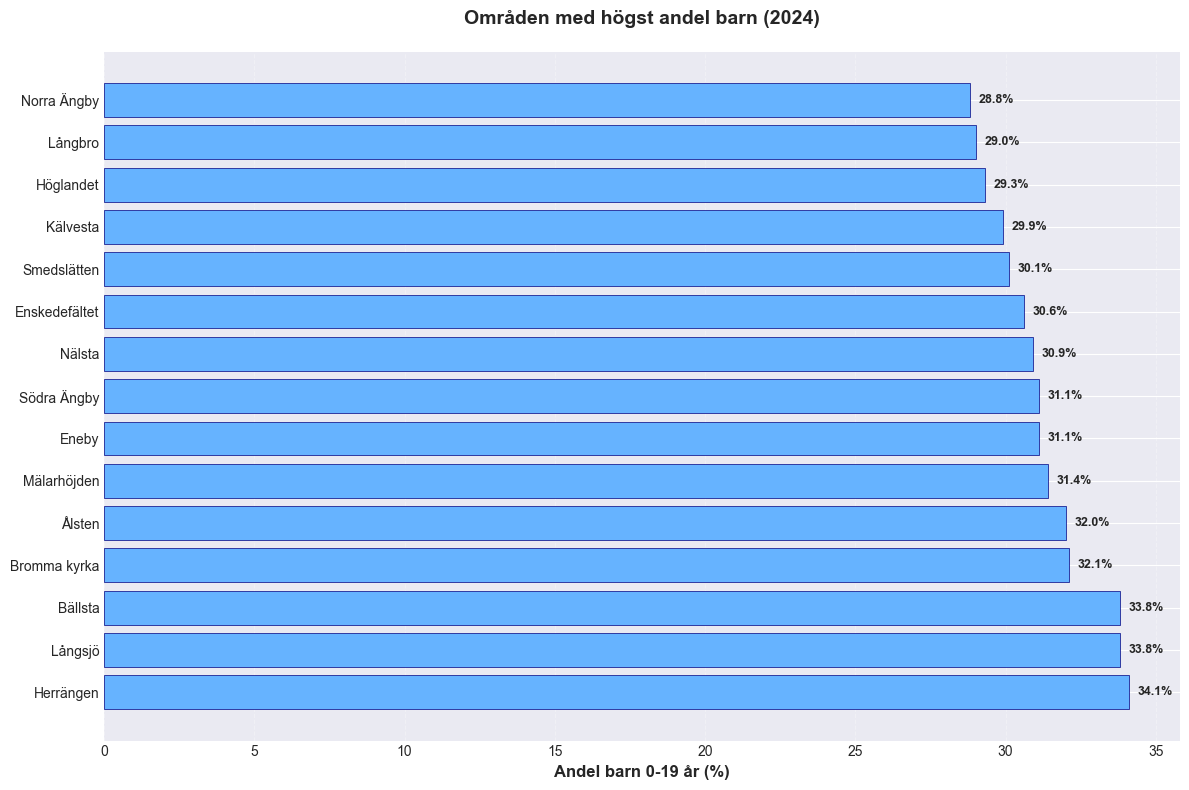

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\omraden_hog_andel_barn.png


In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 1: Områden med högst andel barn
# ═══════════════════════════════════════════════════════════════════════════
# Visar vilka områden som har störst andel barn (0-19 år)
# Användbart för: Familjer som söker barnvänliga områden

# Ta de 15 områdena med högst andel barn
top_barn = df_alder_kat.nlargest(15, 'Barn_%')[['Statistikområde', 'Barn_%']]

# Skapa horisontellt stapeldiagram (lättare att läsa långa områdesnamn)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    range(len(top_barn)),      # Y-positioner (0, 1, 2, ...)
    top_barn['Barn_%'],        # Värden (längd på staplarna)
    color='#66b3ff',           # Ljusblå färg
    edgecolor='navy',          # Mörkblå kant
    linewidth=0.5
)

# Y-axel: Områdesnamn
ax.set_yticks(range(len(top_barn)))
ax.set_yticklabels(top_barn['Statistikområde'])

# X-axel: Procentandel
ax.set_xlabel('Andel barn 0-19 år (%)', fontsize=12, fontweight='bold')

# Titel
ax.set_title('Områden med högst andel barn (2024)', fontsize=14, fontweight='bold', pad=20)

# Lägg till rutnät (gör det lättare att läsa exakta värden)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Lägg till värden på staplarna
for i, (idx, row) in enumerate(top_barn.iterrows()):
    ax.text(row['Barn_%'] + 0.3, i, f"{row['Barn_%']:.1f}%", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()  # Förhindra att labels klipps av
plt.savefig(OUTPUT_DIR / 'omraden_hog_andel_barn.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'omraden_hog_andel_barn.png'}")

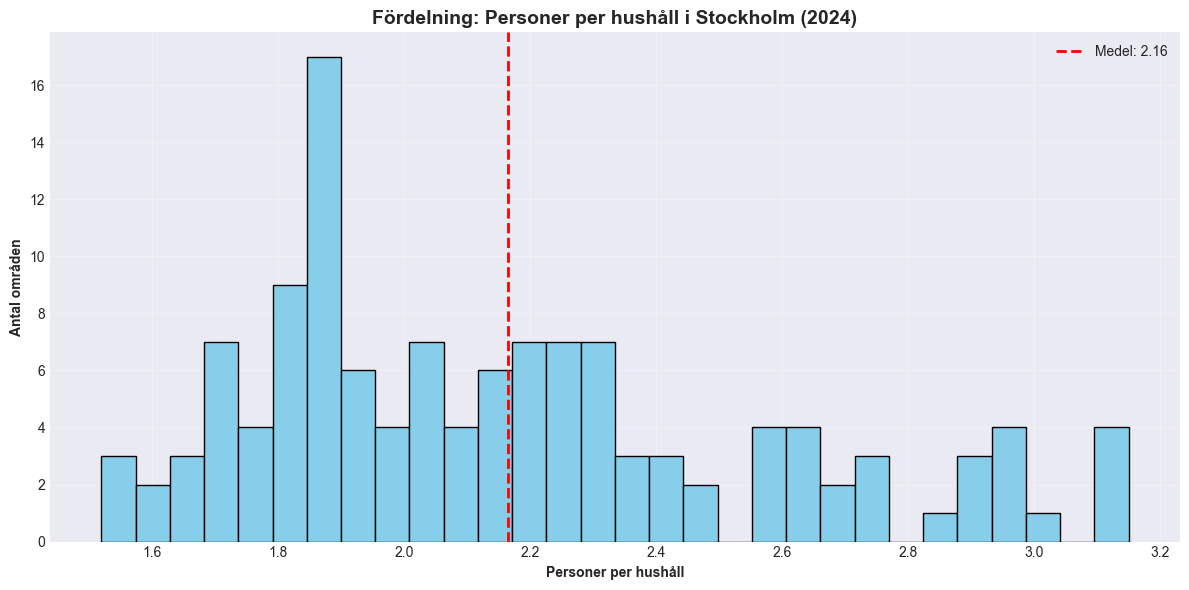

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\personer_per_hushall.png


In [44]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 2: Fördelning av Personer per Hushåll
# ═══════════════════════════════════════════════════════════════════════════
# Histogram som visar spridningen av personer per hushåll
# Bör vara koncentrerat kring 1.5-2.5 för Stockholm

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram med 30 bins (intervall)
ax.hist(
    df_aggregerad['PersonerPerHushall'].dropna(),  # Ta bort NaN-värden
    bins=30,
    color='skyblue',
    edgecolor='black'  # Svarta kanter mellan staplarna
)

# Lägg till vertikal linje för medelvärdet
mean_val = df_aggregerad['PersonerPerHushall'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Medel: {mean_val:.2f}'
)

ax.set_xlabel('Personer per hushåll', fontweight='bold')
ax.set_ylabel('Antal områden', fontweight='bold')
ax.set_title('Fördelning: Personer per hushåll i Stockholm (2024)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'personer_per_hushall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'personer_per_hushall.png'}")

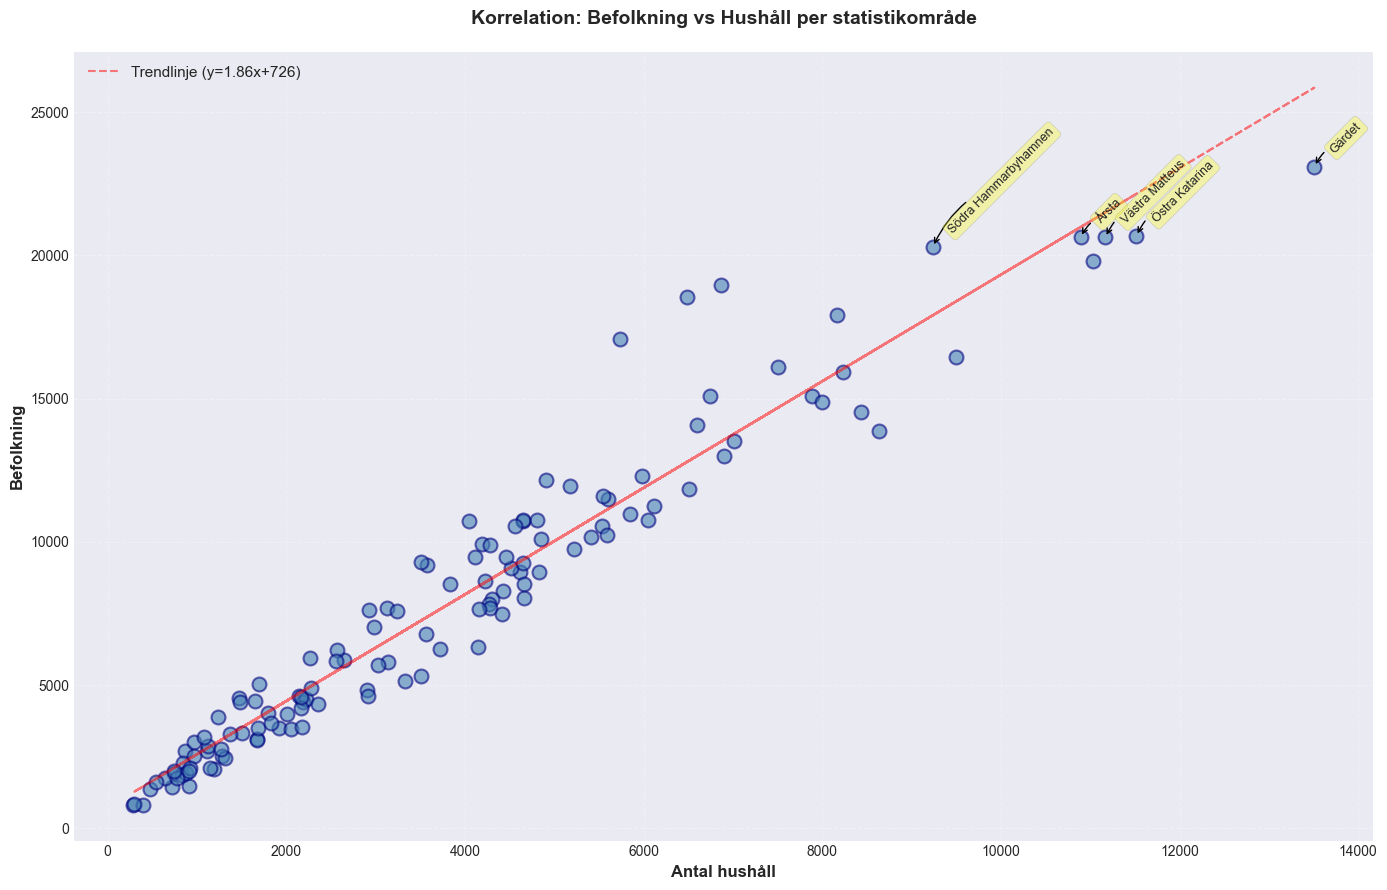

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\korrelation_befolkning_hushall.png


In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 3: Korrelation Befolkning vs Hushåll
# ═══════════════════════════════════════════════════════════════════════════
# Visar sambandet mellan antal invånare och antal hushåll
# Trendlinjen visar genomsnittligt antal personer per hushåll

fig, ax = plt.subplots(figsize=(14, 9))

# Scatter plot med bättre styling
scatter = ax.scatter(
    df_aggregerad['Hushall'], 
    df_aggregerad['Befolkning'],
    s=100,              # Större punkter
    alpha=0.6,          # Transparent så överlapp syns
    edgecolors='navy',  # Mörkare kant
    linewidths=1.5,
    c='steelblue'       # Mjukare färg
)

# Trendlinje (tunnare och mer diskret)
z = np.polyfit(df_aggregerad['Hushall'], df_aggregerad['Befolkning'], 1)
p = np.poly1d(z)
ax.plot(df_aggregerad['Hushall'], p(df_aggregerad['Hushall']), 
        "r--", alpha=0.5, linewidth=1.5, 
        label=f'Trendlinje (y={z[0]:.2f}x+{z[1]:.0f})')

# Märk ut bara extremvärden (top 5 störst befolkning)
top5 = df_aggregerad.nlargest(5, 'Befolkning')
for idx, row in top5.iterrows():
    ax.annotate(
        row['Statistikområde'],
        xy=(row['Hushall'], row['Befolkning']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        rotation=45,  # Rotera 45 grader
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='gray', linewidth=0.5),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', lw=1, color='black')
    )

ax.set_xlabel('Antal hushåll', fontsize=12, fontweight='bold')
ax.set_ylabel('Befolkning', fontsize=12, fontweight='bold')
ax.set_title('Korrelation: Befolkning vs Hushåll per statistikområde', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'korrelation_befolkning_hushall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'korrelation_befolkning_hushall.png'}")

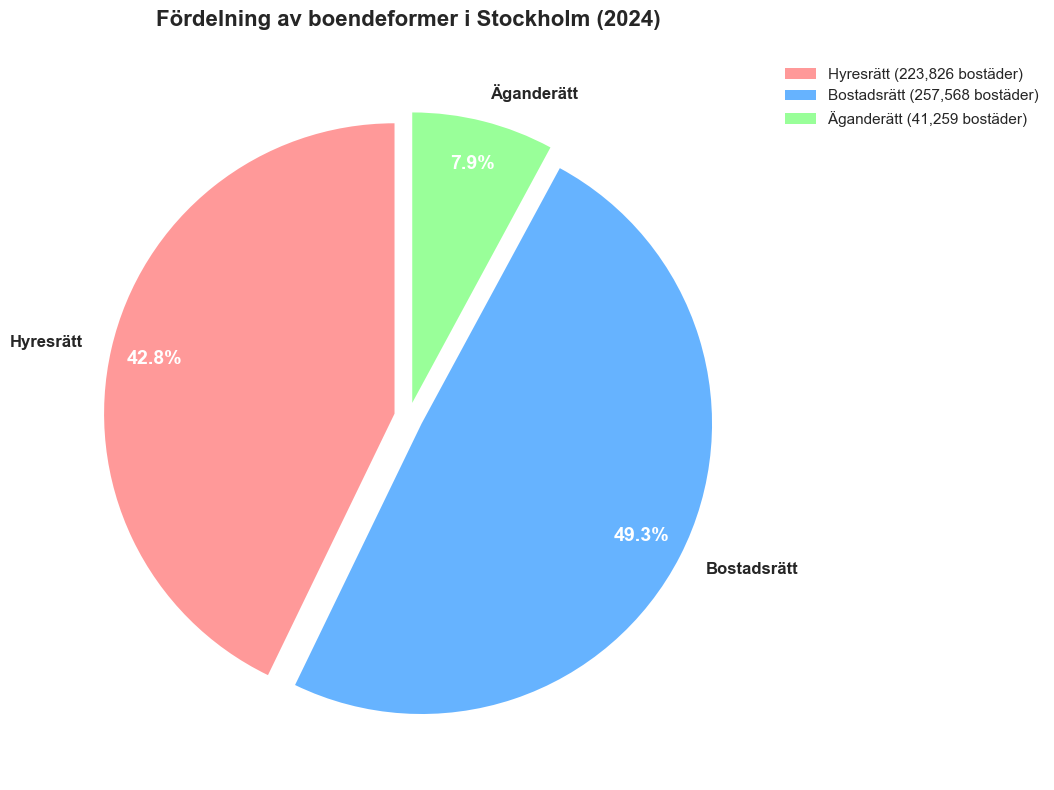

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\boendeform_fordelning.png


In [46]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 4: Cirkeldiagram - Boendeformer
# ═══════════════════════════════════════════════════════════════════════════
# Visar fördelningen av hyresrätt, bostadsrätt och äganderätt i Stockholm

# Beräkna totala bostäder per upplåtelseform
boende_totalt = df_aggregerad[['hyresrätt', 'bostadsrätt', 'äganderätt']].sum()

# Färger (tydliga och professionella)
colors = ['#ff9999', '#66b3ff', '#99ff99']  # Rosa, Blå, Grön
explode = (0.05, 0.05, 0.05)  # Liten separation mellan alla segment

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    boende_totalt,
    labels=['Hyresrätt', 'Bostadsrätt', 'Äganderätt'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'},
    pctdistance=0.85,  # Procenttext längre in
    labeldistance=1.1,  # Labels längre ut
    shadow=False  # INGEN SKUGGA!
)

# Gör procenttexten vit för bättre kontrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

ax.set_title('Fördelning av boendeformer i Stockholm (2024)', 
             fontsize=16, fontweight='bold', pad=20)

# Lägg till legend med antal
legend_labels = [
    f"Hyresrätt ({boende_totalt['hyresrätt']:,.0f} bostäder)",
    f"Bostadsrätt ({boende_totalt['bostadsrätt']:,.0f} bostäder)",
    f"Äganderätt ({boende_totalt['äganderätt']:,.0f} bostäder)"
]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boendeform_fordelning.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'boendeform_fordelning.png'}")

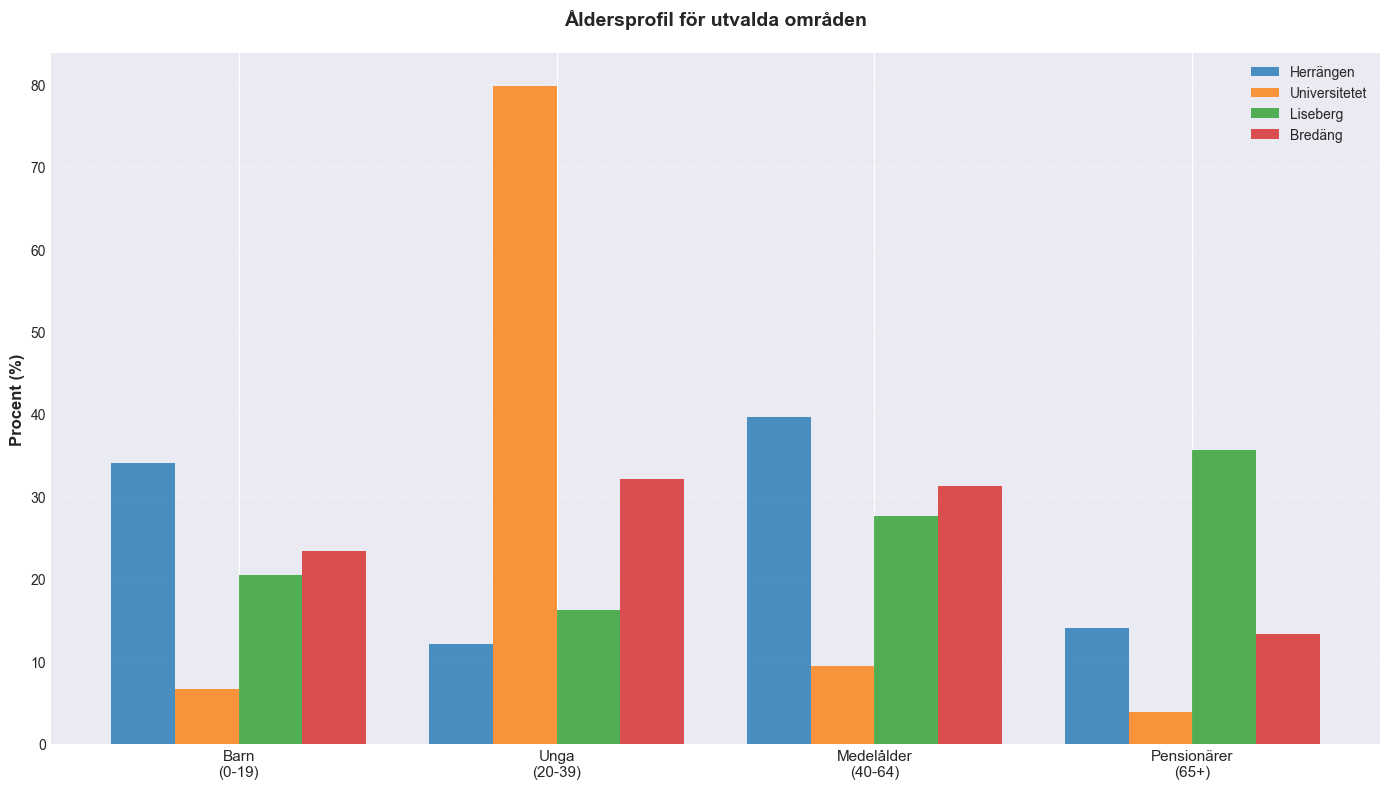

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\aldersprofil_jamforelse.png


In [47]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 5: Ålderspyramid för utvalda områden
# ═══════════════════════════════════════════════════════════════════════════
# Jämför åldersstrukturen i 4 olika typer av områden

# Välj representativa områden
utvalda = [
    df_alder_kat.nlargest(1, 'Barn_%').iloc[0]['Statistikområde'],      # Mest barn
    df_alder_kat.nlargest(1, 'Unga_%').iloc[0]['Statistikområde'],      # Mest unga
    df_alder_kat.nlargest(1, 'Pensionärer_%').iloc[0]['Statistikområde'], # Mest pensionärer
    'Södermalm' if 'Södermalm' in df_alder_kat['Statistikområde'].values else df_alder_kat.iloc[0]['Statistikområde']
]

# Ta bort dubbletter
utvalda = list(dict.fromkeys(utvalda))[:4]

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(4)  # 4 ålderskategorier
width = 0.2

for i, omrade in enumerate(utvalda):
    data = df_alder_kat[df_alder_kat['Statistikområde'] == omrade].iloc[0]
    values = [data['Barn_%'], data['Unga_%'], 
              (data['Medelålder_40_64']/data['TotalBefolkning']*100), 
              data['Pensionärer_%']]
    ax.bar([p + width*i for p in x], values, width, label=omrade, alpha=0.8)

ax.set_ylabel('Procent (%)', fontsize=12, fontweight='bold')
ax.set_title('Åldersprofil för utvalda områden', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks([p + width*1.5 for p in x])
ax.set_xticklabels(['Barn\n(0-19)', 'Unga\n(20-39)', 'Medelålder\n(40-64)', 'Pensionärer\n(65+)'],
                   fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aldersprofil_jamforelse.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'aldersprofil_jamforelse.png'}")

---
## SAMMANFATTNING

Översikt över vad som hämtats och skapats.

In [48]:
print("\n" + "="*60)
print("SAMMANFATTNING")
print("="*60)

print(f"\n📊 RAW DATA (med all detalj):")
print(f"   Folkmängd: {len(df_folkm)} rader ({len(regso_folkm)} områden × {len(aldersgrupper)} åldersgrupper)")
print(f"   Hushåll: {len(df_hushall)} rader ({len(regso_hushall)} områden × {len(hushall_cats)} typer)")
print(f"   Boende: {len(df_boende)} rader ({len(regso_boende)} områden × {len(boende_cats)} former)")

print(f"\n📈 AGGREGERAD DATA:")
print(f"   {len(df_aggregerad)} områden")
print(f"   {df_aggregerad['Befolkning'].sum():,.0f} invånare totalt")
print(f"   {df_aggregerad['Hushall'].sum():,.0f} hushåll totalt")
print(f"   {df_aggregerad['TotalBostader'].sum():,.0f} bostäder totalt")
print(f"   Medel {df_aggregerad['PersonerPerHushall'].mean():.2f} personer/hushåll")

print(f"\n💾 FILER SKAPADE:")
print(f"   {DATA_DIR / 'stockholm_folkm_regso_2024.csv'} (RAW med 17 åldersgrupper)")
print(f"   {DATA_DIR / 'stockholm_hushall_regso_2024.csv'} (RAW med alla hushållstyper)")
print(f"   {DATA_DIR / 'stockholm_boende_regso_2024.csv'} (RAW med alla boendeformer)")
print(f"   {DATA_DIR / 'stockholm_aggregerad_2024.csv'} (AGGREGERAD för analys)")

print(f"\n📊 GRAFER SKAPADE:")
print(f"   {OUTPUT_DIR / 'barnvanliga_omraden.png'}")
print(f"   {OUTPUT_DIR / 'personer_per_hushall.png'}")
print(f"   {OUTPUT_DIR / 'korrelation_befolkning_hushall.png'}")
print(f"   {OUTPUT_DIR / 'boendeform_fordelning.png'}")
print(f"   {OUTPUT_DIR / 'aldersprofil_jamforelse.png'}")

print("\n✅ KLART!")
print("="*60)


SAMMANFATTNING

📊 RAW DATA (med all detalj):
   Folkmängd: 2159 rader (127 områden × 17 åldersgrupper)
   Hushåll: 762 rader (127 områden × 6 typer)
   Boende: 508 rader (127 områden × 4 former)

📈 AGGREGERAD DATA:
   127 områden
   995,574 invånare totalt
   485,661 hushåll totalt
   522,653 bostäder totalt
   Medel 2.16 personer/hushåll

💾 FILER SKAPADE:
   c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_folkm_regso_2024.csv (RAW med 17 åldersgrupper)
   c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_hushall_regso_2024.csv (RAW med alla hushållstyper)
   c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_boende_regso_2024.csv (RAW med alla boendeformer)
   c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_aggregerad_2024.csv (AGGREGERAD för analys)

📊 GRAFER SKAPADE:
   c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\barnvanliga_omraden.png
   c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\personer_per_hushal